In [1]:
import torch
# torch.autograd.set_detect_anomaly(True)
from torch.utils.data import DataLoader,WeightedRandomSampler
from torch.optim.lr_scheduler import PolynomialLR
import torch.nn.functional as F
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import (
    plot_some_images ,read_images ,
    pre_hard_skeletonize , pre_soft_skeletonize,
    compute_confution_matrix,draw_mask,TP_TN_FP_FN,)
from utils.preprocessing import (
    WhiteTopHat , CLAHE , normalize_xca,
    BrightnessMultiplicativeNNUNet2D,
    ContrastAugmentationNNUNet2D)
from utils.dataset import  UnetDataset , ValidUnetDataset 
from models.nnunet import nnUnet
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###
from trainer import evaluation

In [2]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 4 ,
    "attention" : False,
    "k":40,
    "batch_size" : 20,
    "num_workers" : 5,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":200,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.8,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "15-14b-4layer",
    "deep_super_vision" : False,
    "f_alpha":None,
    "layer_count":4
}
# class_map = {
#     1: '1',2: '2', 3: '3',4: '4',
#     5: '5',6: '6',7: '7',8: '8',
#     9: '9',10: '9a',11: '10',12: '10a',
#     13: '11',14: '12',15: '12a',16: '13',
#     17: '14',18: '14a',19: '15',20: '16',
#     21: '16a',22: '16b',23: '16c',
#     24: '12b',25: '14b'
# }
class_map = {
    1:'16a',
    2:'16b',
    3:'16c'
}
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","CE loss",args["loss_type"]]
out_counts = args["layer_count"] if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights



[1.0]

In [3]:
b=0.999
train_class_counts = [
    1200,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
# f_alpha = (1-b)/(1-np.power(b,train_class_counts))
total = np.sum(train_class_counts)
f_alpha = np.log(total/np.array(train_class_counts))
f_alpha = (f_alpha / f_alpha.mean()).tolist()
# args["f_alpha"] = [0.1,1.75,1.5]
args["f_alpha"]=[0.1 ,1,1,1]
f_alpha


[0.4192306623653949,
 0.7179025174767664,
 0.7172184312490237,
 0.7213506198648413,
 0.7718364322603585,
 0.6310175618202434,
 0.6310175618202434,
 0.7423200457906856,
 0.7659851796135413,
 0.8808365687040562,
 1.1472158488751967,
 1.4556618102528003,
 2.235638440011511,
 0.7578514761453713,
 1.1824730889495298,
 0.9906024194367986,
 0.7701509647332515,
 1.0385057663997224,
 1.238592452721393,
 1.3037247322439667,
 0.8402380298539683,
 1.2720560555504503,
 1.2438749107979519,
 1.3558847771047964,
 1.1742081741391486,
 0.9946054718189865]

In [4]:
# args["t_alpha"] = [1,0.8]
args["t_alpha"] = None

In [5]:


train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
        A.Downscale(
        scale_range=[0.7, 1],
        interpolation_pair={"downscale": 0, "upscale": 0},
        p=0.5
    ),
    A.GaussNoise(
        std_range=[0.0, 0.1],
        mean_range=[0, 0],
        per_channel=True,
        noise_scale_factor=1,
        p=0.5
    ),
    A.GaussianBlur(
        sigma_limit=[1.0,1.5],
        blur_limit = (3,7),
        p=0.5
    ),

    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.5),
    A.Compose([
        A.InvertImg(p=1.0),
        A.RandomGamma(gamma_limit=(70, 150), p=1.0),
        A.InvertImg(p=1.0),
    ], p=0.5),
    BrightnessMultiplicativeNNUNet2D(multiplier_range=(0.70, 1.3), p=0.5),
    ContrastAugmentationNNUNet2D(contrast_range=(0.65, 1.5), p=0.5),
    A.RandomGamma(
        gamma_limit=(90, 120), 
        p=0.5
    ),
    A.Affine(
        scale=(0.7, 1.4),  
        translate_percent=(0, 0),
        rotate=0,               
        shear=0,                 
        fit_output=False, 
        p=0.5
    ),
    A.Rotate(limit=30, p=0.5, fill_mask = 0),
    A.Rotate(limit=-30, p=0.5, fill_mask = 0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # A.Lambda(image=normalize_xca)
    A.Normalize(
        mean=(0.485,), 
        std=(0.229,),
        max_pixel_value=255.0, 
        p=1.0),
    ]
)
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    A.Normalize(
        mean=(0.485,), 
        std=(0.229,),
        max_pixel_value=255.0, 
        p=1.0),
    ToTensorV2()
    ]  
)

train_preprocess = None


/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:47: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:60: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [6]:
train_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "train",chosen_labels=[21,22,23])
valid_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "val",chosen_labels=[21,22,23])


NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
sampler_weights = []
empty_list = []
fg_list = []
just_16c = []
for img,label in train_images:
    u = np.unique(label)
    if(len(u)==1):
        empty_list+=[[img,label]]
    elif(len(u)==2 and 3 in u):
        just_16c += [[img,label]]
    else:
        fg_list+=[[img,label]]


print(len(empty_list),len(fg_list),len(just_16c))
empty_size = 922
empty_list = random.sample(empty_list,k=empty_size)
sampler_weights += [0.003]*empty_size + [0.09]*len(fg_list) + [0.22]*len(just_16c)
new_train_images = empty_list + fg_list + just_16c


922 68 10


In [8]:

train_ds = UnetDataset(transform = train_transforms,data = new_train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)
sampler = WeightedRandomSampler(
    weights=sampler_weights, 
    num_samples=len(sampler_weights),
    replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size = args["batch_size"] ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=False,
    sampler=sampler
)
valid_loader = DataLoader(
    valid_ds,
    batch_size = 10 ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=False,
)


In [9]:
# ls_16a = [0 for i in range(len(train_loader))]
# ls_16b = [0 for i in range(len(train_loader))]
# ls_16c = [0 for i in range(len(train_loader))]
# empty = [0 for i in range(len(train_loader))]
# i=0
# for img , labels in train_loader:
#     label = labels[0]
#     for l in label:
#         u = np.unique(l)
#         if(1 in u):
#             ls_16a[i]+=1
#         if(2 in u):
#             ls_16b[i]+=1
#         if(3 in u):
#             ls_16c[i]+=1
#         if(len(u)==1):
#             empty[i]+=1 
#     i+=1
# plt.figure(figsize=(20,5))
# plt.plot(ls_16a,label="16a") 
# plt.plot(ls_16b,label="16b") 
# plt.plot(ls_16c,label="16c") 
# plt.plot(empty,label="empty")
# plt.legend() 

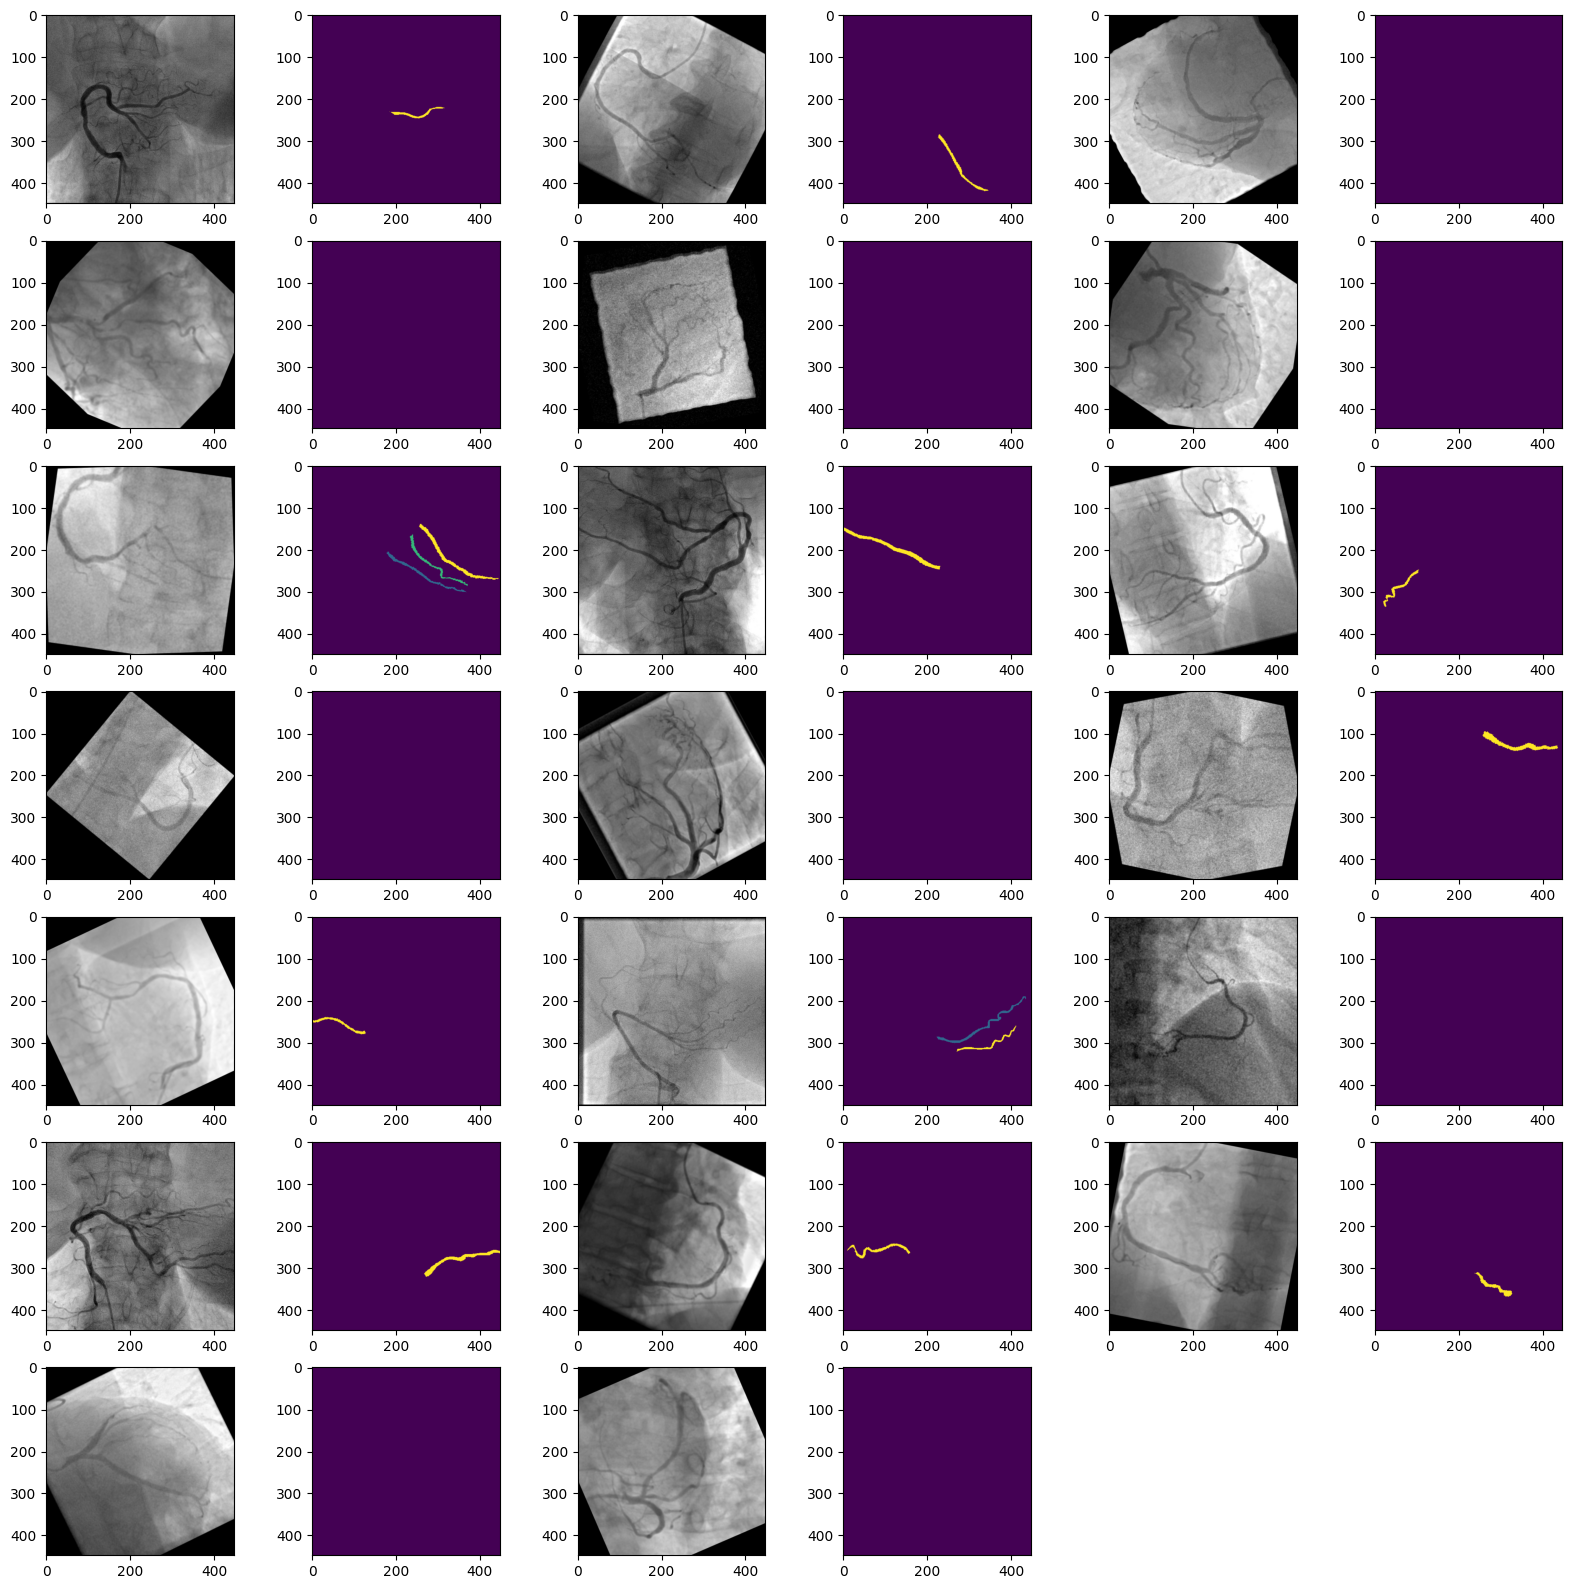

In [10]:
imgs , labels = next(iter(train_loader))
labels=labels[0]
plt.figure(figsize=(20,20))
i=1
for j,img in enumerate(imgs):

    plt.subplot(7,6,i)
    plt.imshow(img[0].numpy(),cmap="gray")
    plt.subplot(7,6,i+1)
    plt.imshow(labels[j].numpy()*50)
    i+=2

In [11]:
class Unet(torch.nn.Module):
    def __init__(self, args):
        super(Unet,self).__init__()
        self.model = smp.Unet(
            encoder_name="resnet18",     # Reliable backbone
            encoder_weights="imagenet",  # Start with pre-trained edges
            in_channels=1,               # Grayscale adaptation
            classes=args["class_count"],                   # Bg, 14b, 15
            encoder_depth=3,

            decoder_channels=(64, 32, 16) 
        )
        # for param in self.model.encoder.parameters():
        #     param.requires_grad = False
        # for param in self.model.encoder.features[-1].parameters():
        #     param.requires_grad = True
    def forward(self,x):
        return [self.model(x)]
    

In [12]:

# model = nnUnet(args).to(args["device"])

model = Unet(args).to(args["device"])


loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
optimizer = torch.optim.SGD(
    model.parameters(),
    momentum=args["momentum"],
    lr=args["lr"],
    nesterov=True,
    weight_decay=args["weight_decay"]
)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map,class_count=args["class_count"]-1)


best_model = trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)




loss is set to tversky


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

current lr : 0.01
train ==> epcoh (0)
total loss : 1.2550215435028076 - CE loss : 0.2973043814301491 - tversky loss : 0.9577171552181244

train avg metrics for epoch 0 :
avg dice : 0.0021015386834430196 - avg precision : 0.001610917931733032 - avg recall : 0.007941717495365689
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.0506827712059021 - CE loss : 0.06660131607204675 - tversky loss : 0.9840814560651779

valid avg metrics for epoch 0 :
avg dice : 8.394268714735179e-13 - avg precision : 0.0 - avg recall : 0.0
------------------------------------------------------------
New Best! : dice = 8.394268895435542e-13


  0%|          | 0/50 [00:00<?, ?it/s]

...

current lr : 0.0002283
train ==> epcoh (197)
total loss : 0.1802871696650982 - CE loss : 0.06369455553591251 - tversky loss : 0.11659261375665665

train avg metrics for epoch 197 :
avg dice : 0.6710027853647867 - avg precision : 0.5845402479171753 - avg recall : 0.7875152230262756
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (197)
total loss : 1.0127311438322066 - CE loss : 0.06356566292233765 - tversky loss : 0.9491654932498932

valid avg metrics for epoch 197 :
avg dice : 0.04895743727684021 - avg precision : 0.035969750645260014 - avg recall : 0.07664752503236134
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

current lr : 0.0001585
train ==> epcoh (198)
total loss : 0.180392501950264 - CE loss : 0.06276647105813027 - tversky loss : 0.11762603268027305

train avg metrics for epoch 198 :
avg dice : 0.6729254126548767 - avg precision : 0.5896959900856018 - avg recall : 0.7835170229276022
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (198)
total loss : 1.0155234545469285 - CE loss : 0.06399056746158749 - tversky loss : 0.9515328854322433

valid avg metrics for epoch 198 :
avg dice : 0.04711792555948099 - avg precision : 0.03570417190591494 - avg recall : 0.06938907566169898
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

current lr : 8.493e-05
train ==> epcoh (199)
total loss : 0.17827872678637505 - CE loss : 0.06515649784356356 - tversky loss : 0.11312222756445407

train avg metrics for epoch 199 :
avg dice : 0.6830524802207947 - avg precision : 0.6076952616373698 - avg recall : 0.779765784740448
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (199)
total loss : 1.0149271935224533 - CE loss : 0.06417041991371661 - tversky loss : 0.9507567763328553

valid avg metrics for epoch 199 :
avg dice : 0.048223404213786125 - avg precision : 0.03650287973384062 - avg recall : 0.0713303027053674
16a => dice : 0.018645932897925377 p : 0.014374369755387306 , r : 0.026529613882303238
16b => dice : 0.07777866721153259 p : 0.057404302060604095 , r : 0.1205735132098198
16c => dice : 0.048245612531900406 p : 0.03772996738553047 , r : 0.06688778102397919
------------------------------------------------------------
best result at epoch 39 with dice 0.07485801726579666


In [13]:
with torch.no_grad():
    evaluation(
        recorder=recorder,
        model=best_model,
        loss_fn=loss_fn,
        valid_loader=valid_loader,
        class_count=args["class_count"],
        class_wise_report=True,
        epoch=0,
        device=args["device"]
    )

valid ==> epcoh (0)
total loss : 0.9622960954904556 - CE loss : 0.04504096191376448 - tversky loss : 0.9172551363706589

valid avg metrics for epoch 0 :
avg dice : 0.07485801726579666 - avg precision : 0.04825503006577492 - avg recall : 0.22531312704086304
16a => dice : 0.11328846216201782 p : 0.08141078054904938 , r : 0.18619677424430847
16b => dice : 0.057018790394067764 p : 0.03139689937233925 , r : 0.3099932074546814
16c => dice : 0.0542667992413044 p : 0.03195741027593613 , r : 0.17974939942359924
------------------------------------------------------------


Save Model
Saving Memory
Saving All Plots


  0%|          | 0/20 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/18 [00:00<?, ?it/s]

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 11/11 [00:00<00:00, 3235.44it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  5.82it/s]

processing ./temp_script.py


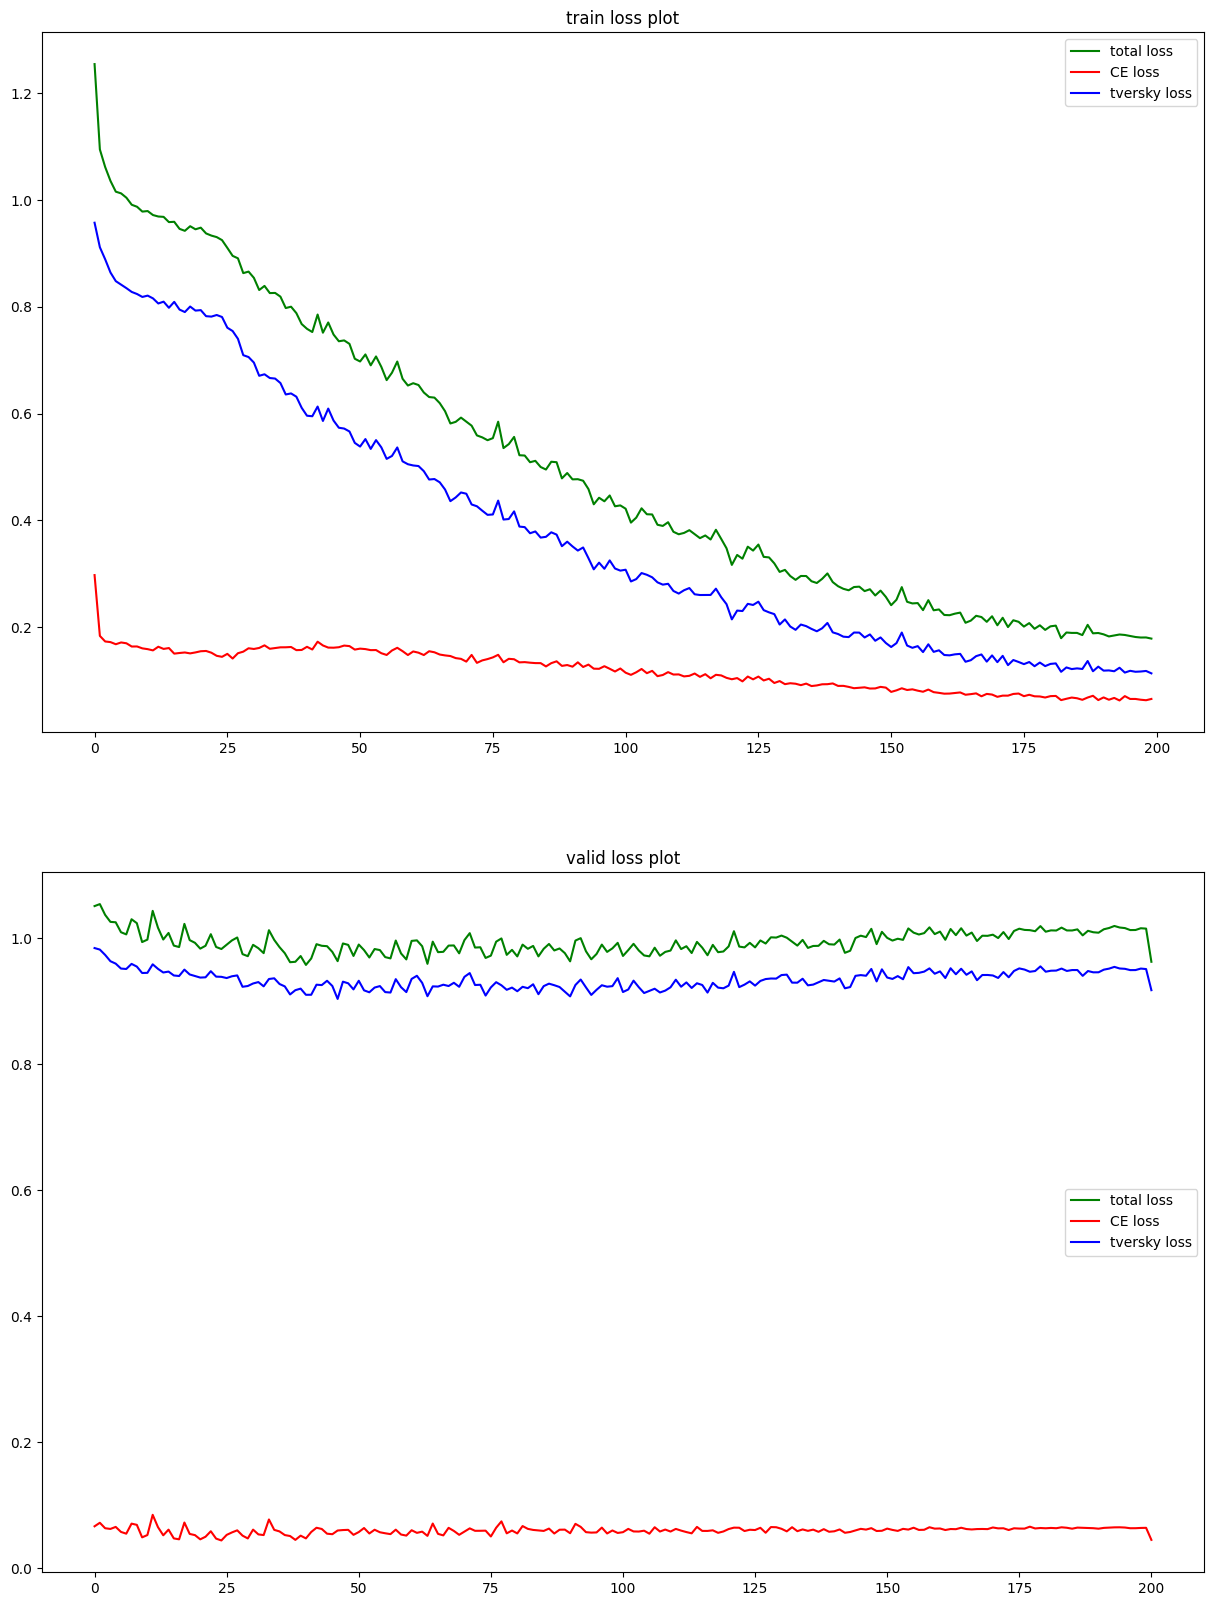

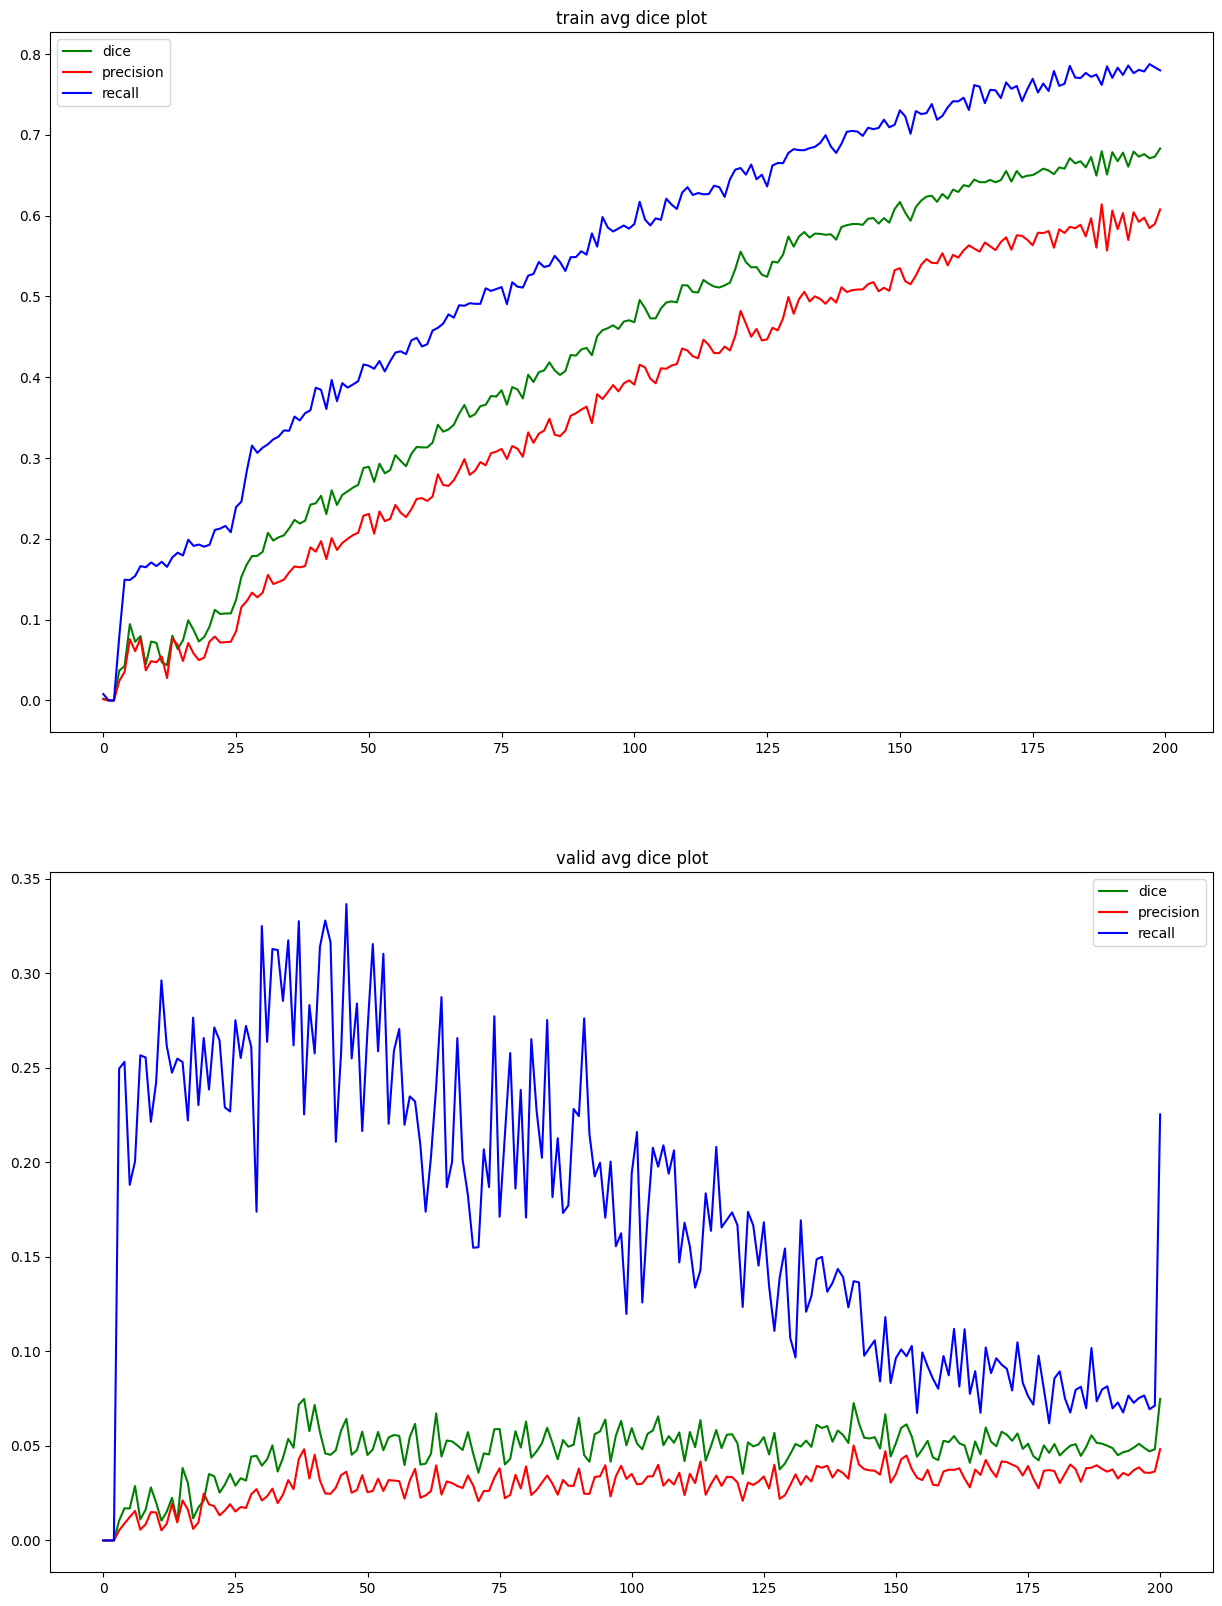

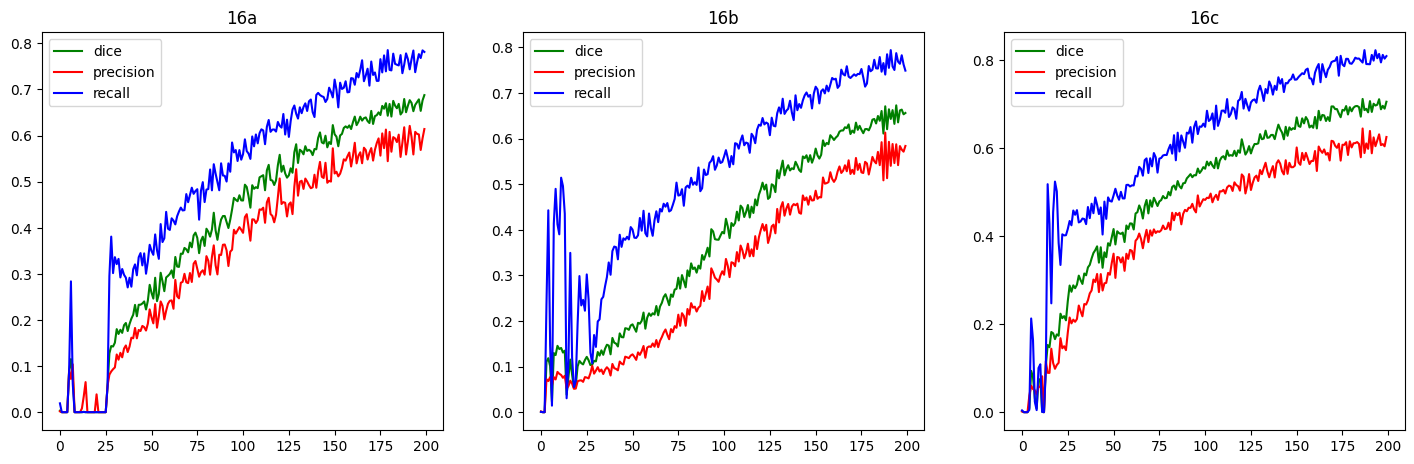

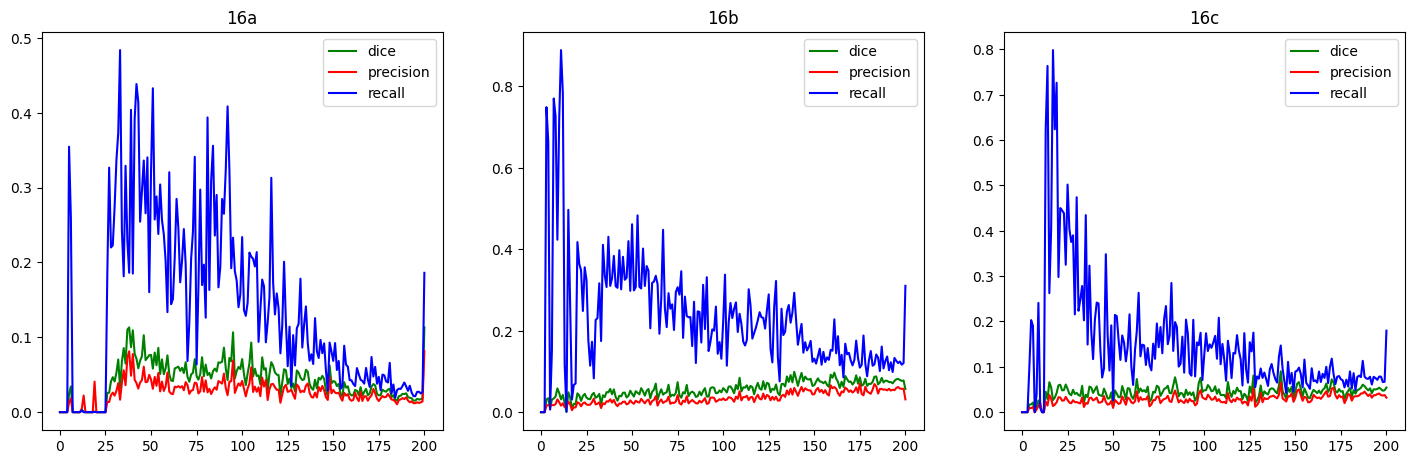

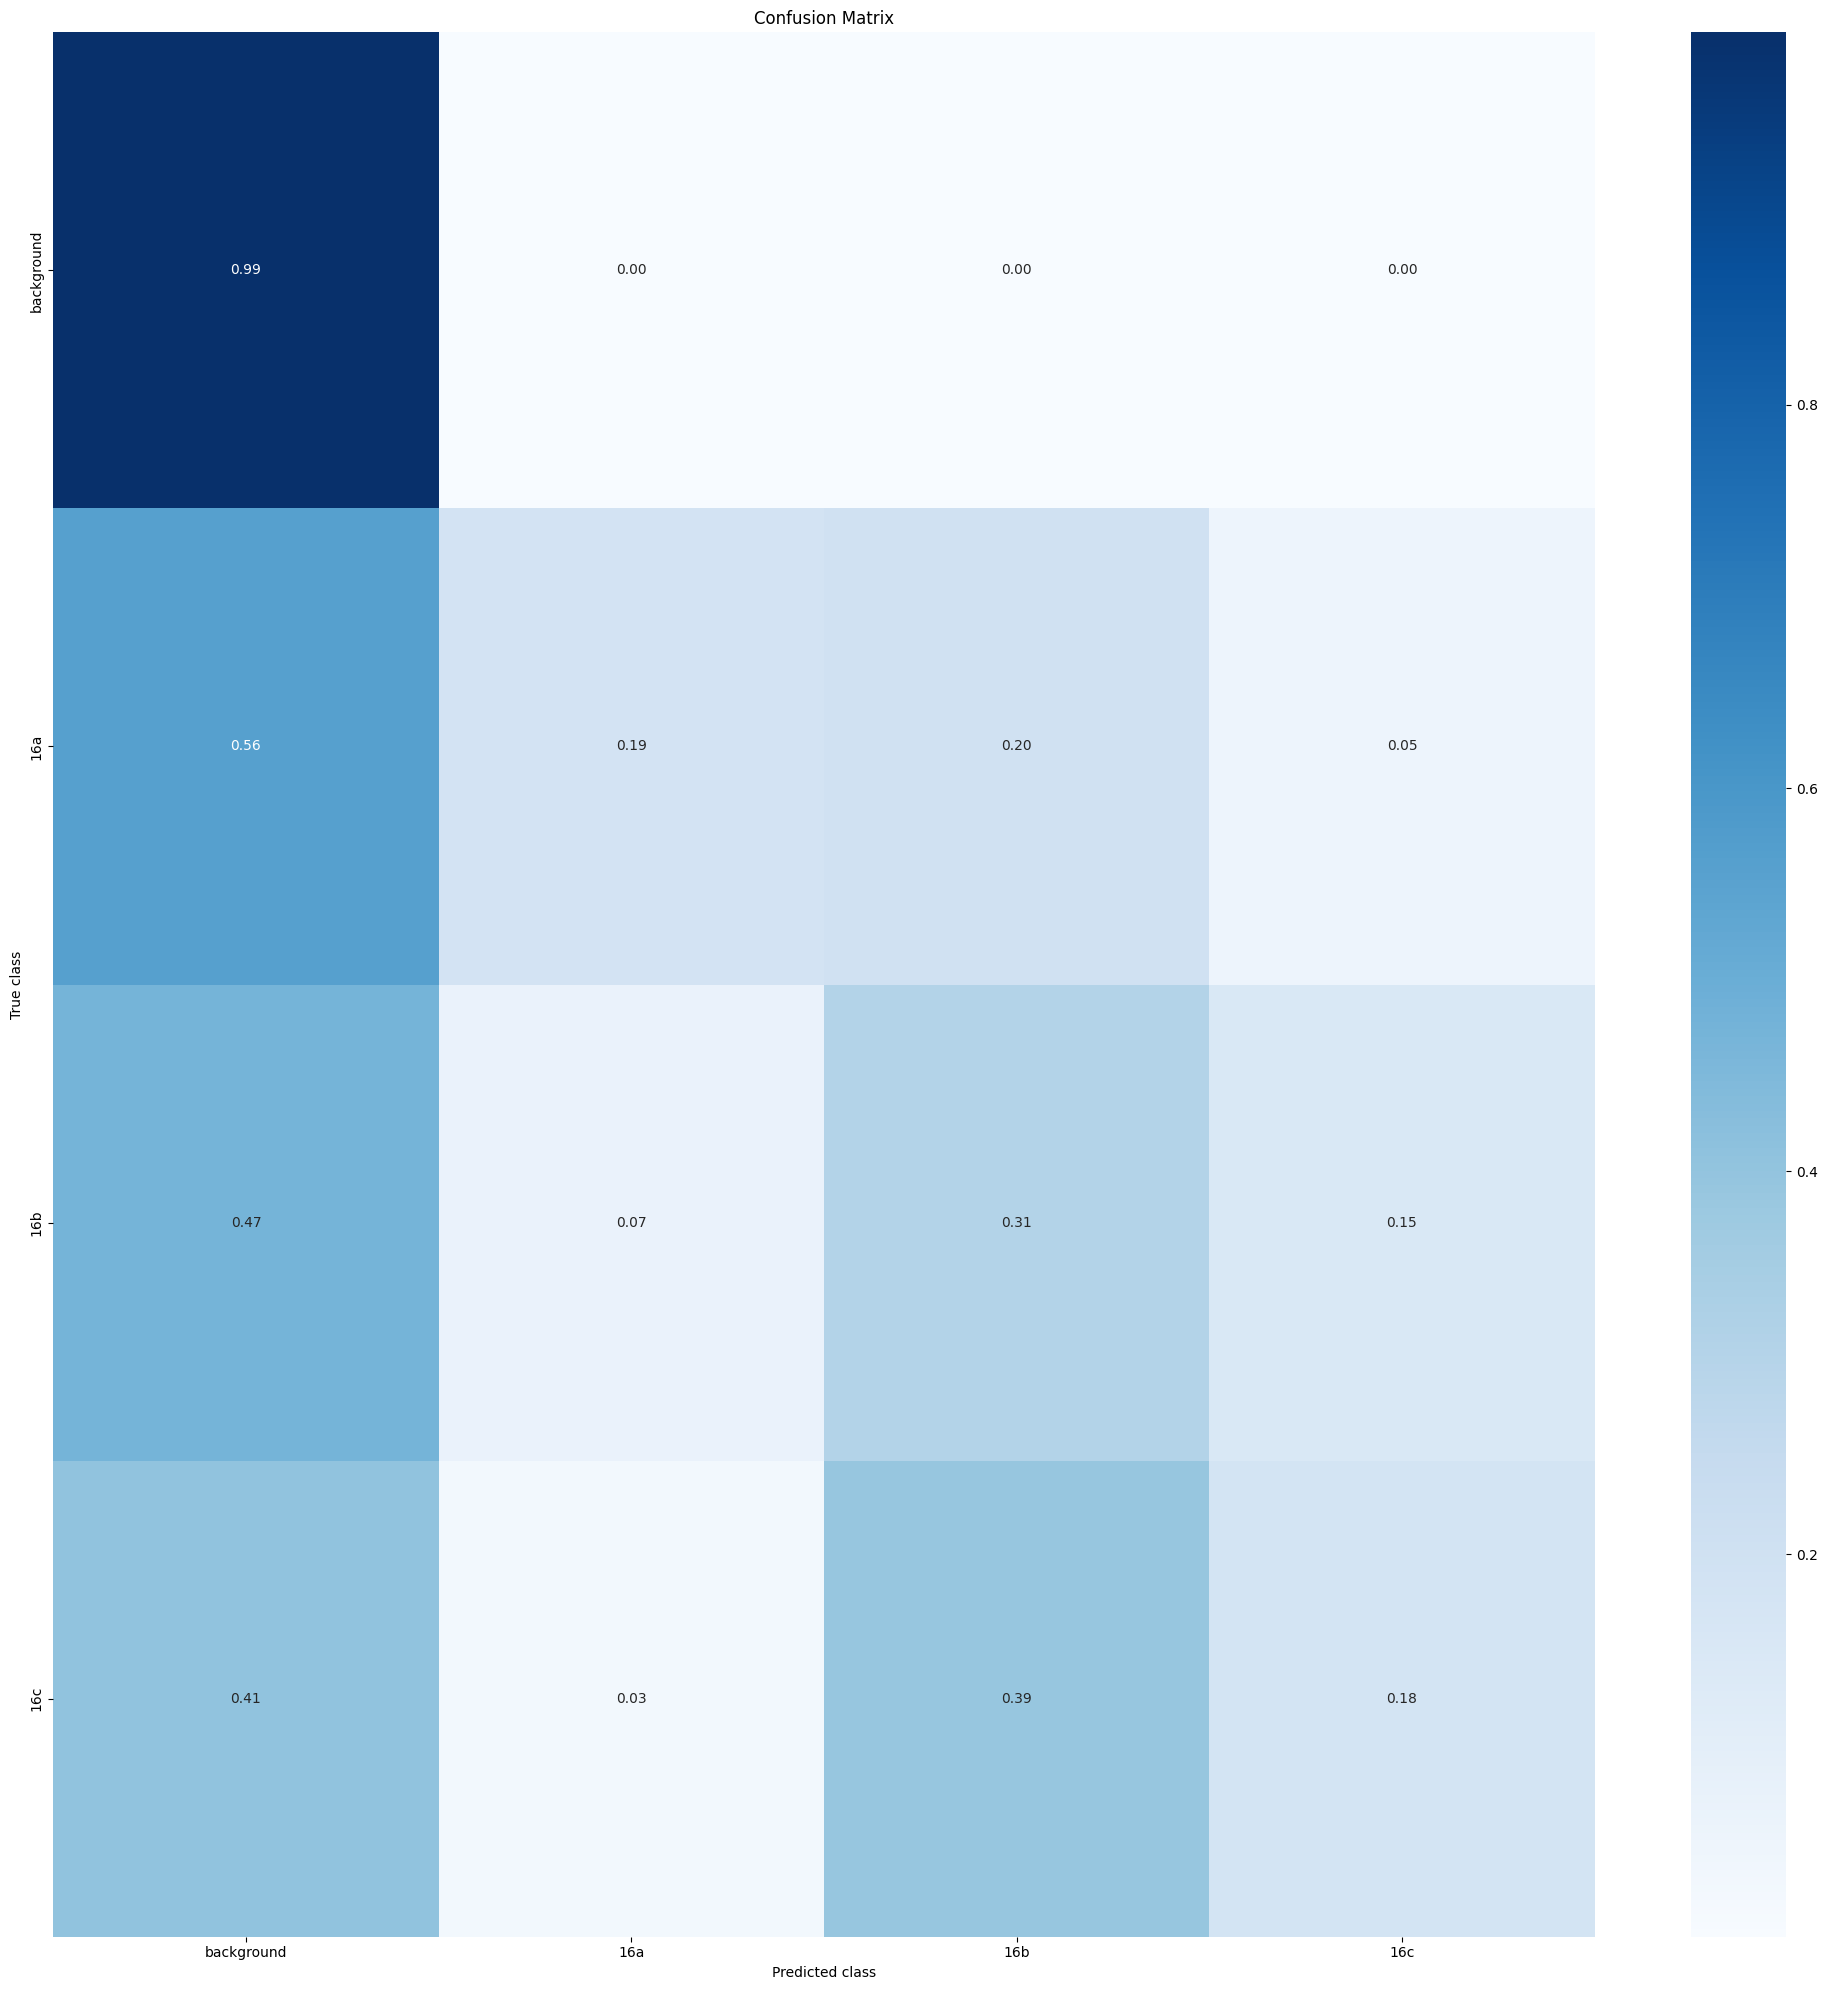

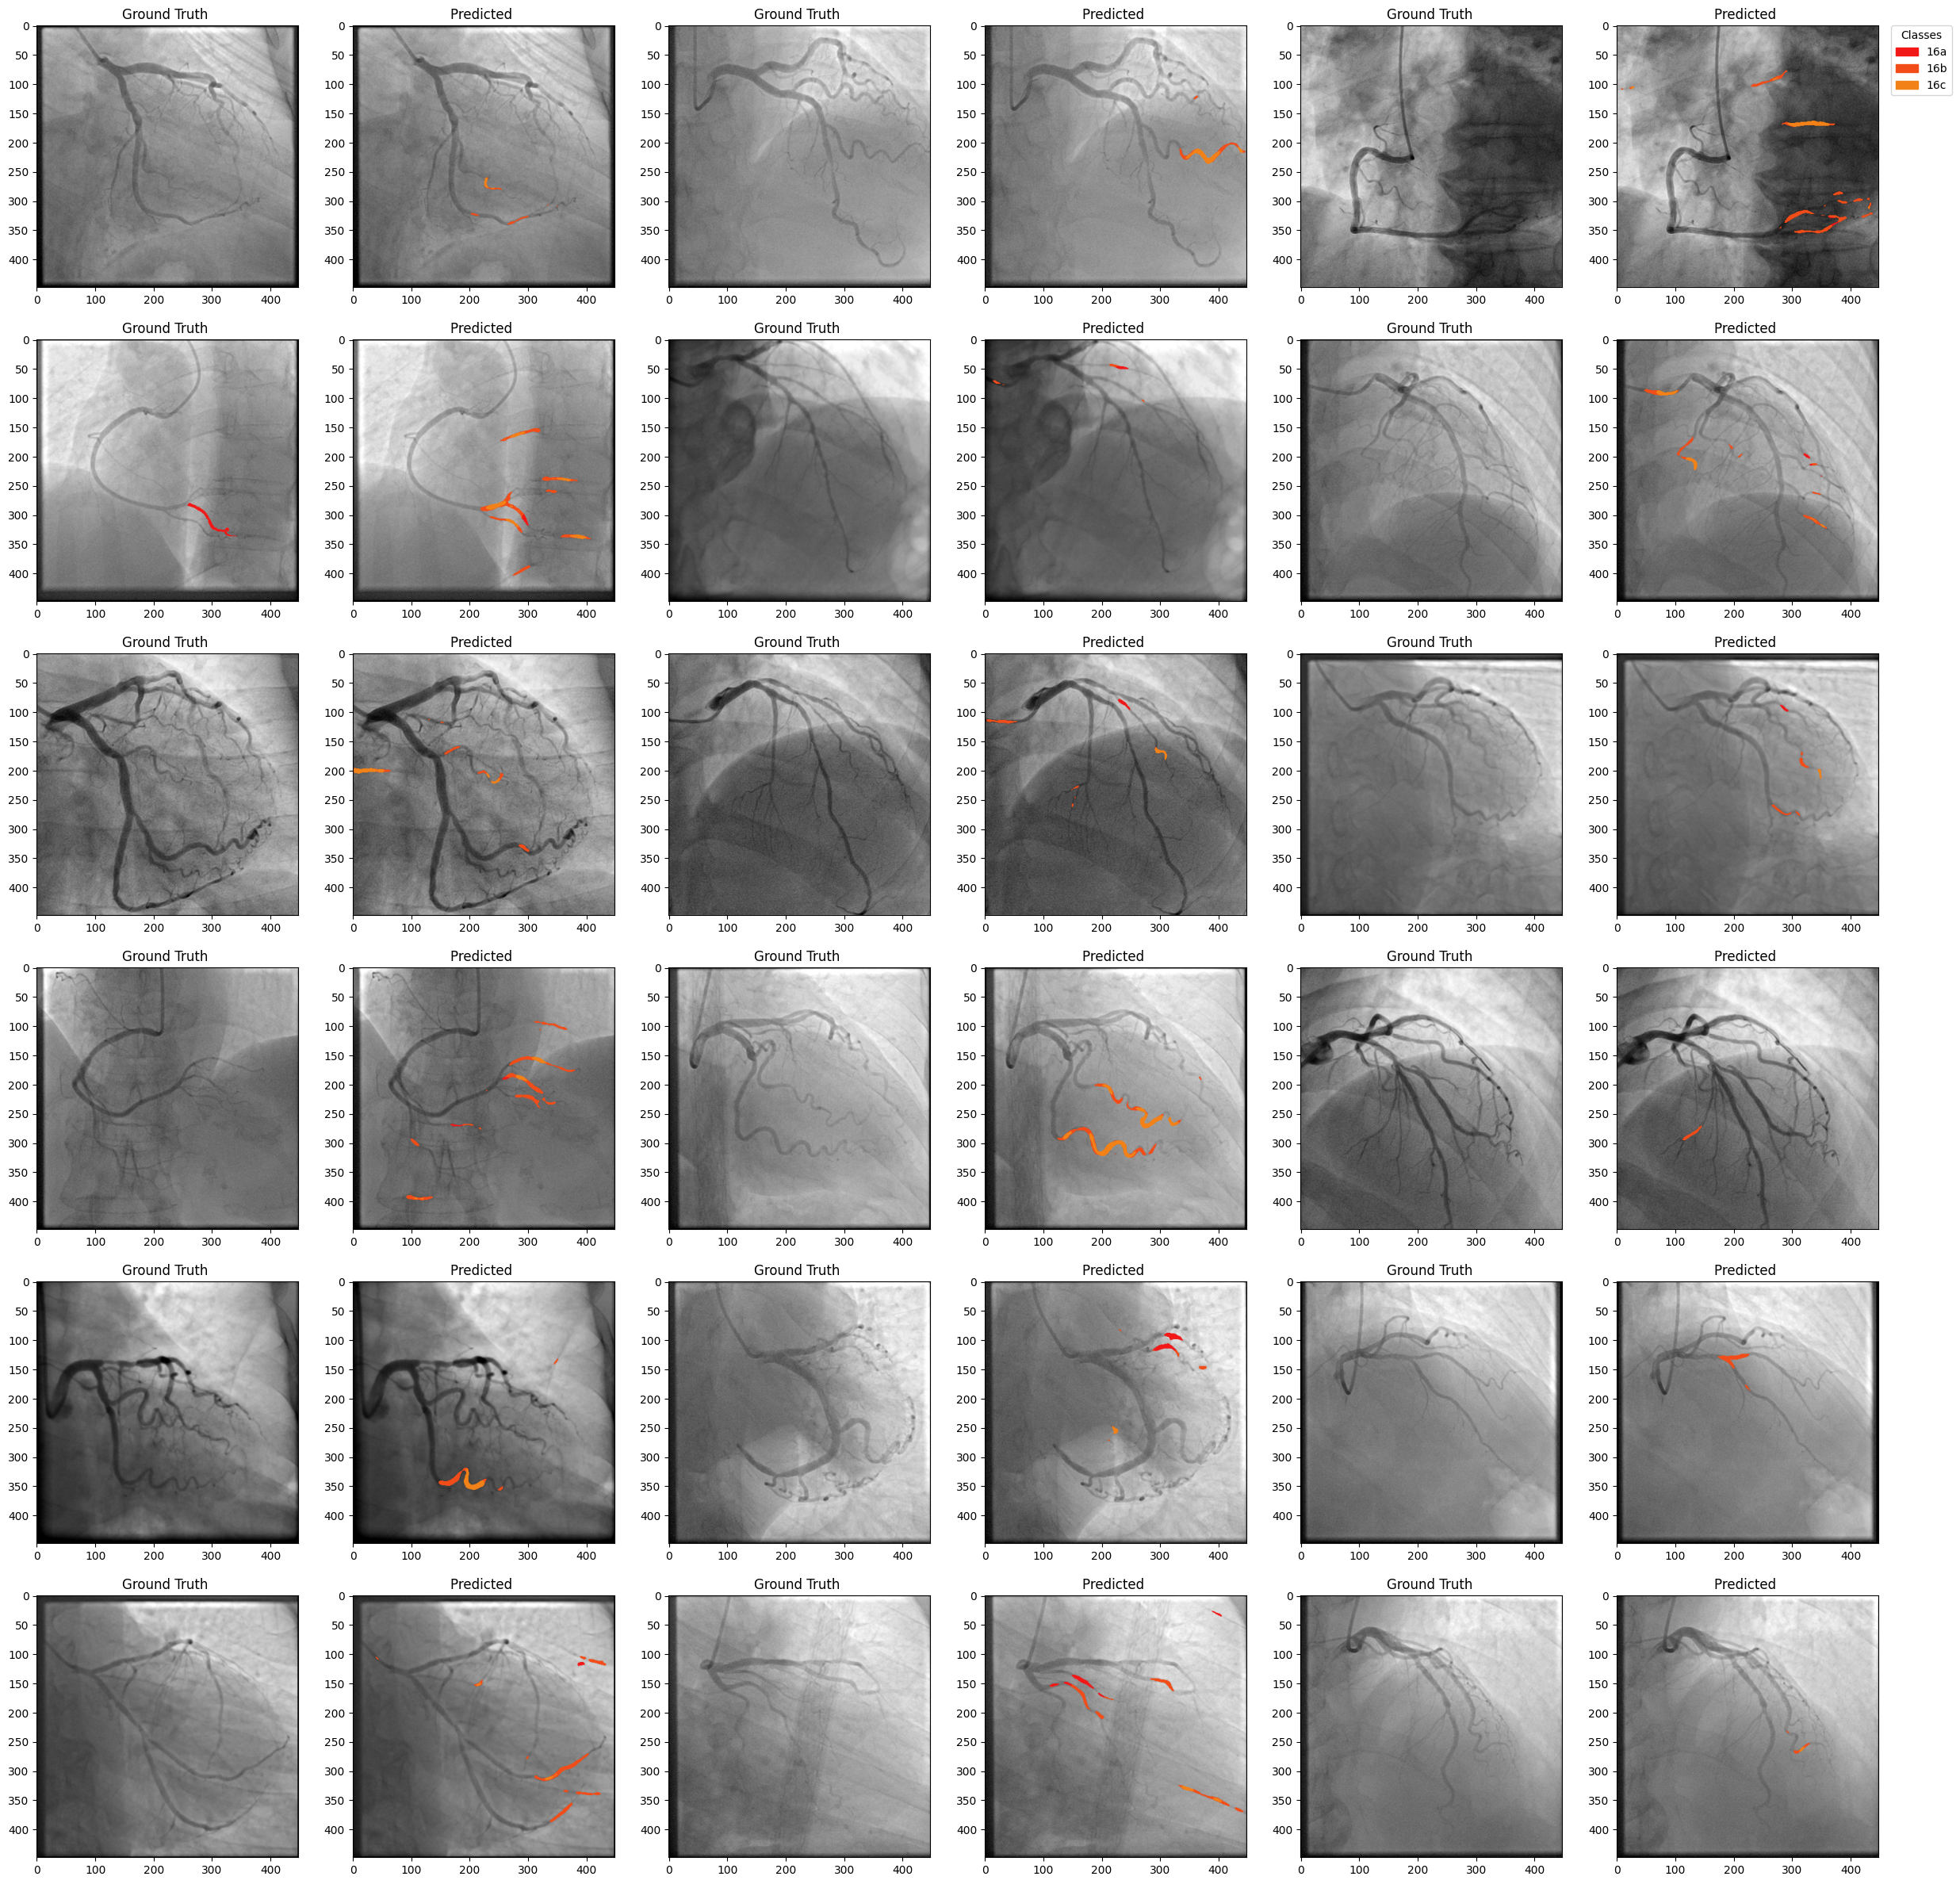

In [14]:


save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"]
)
